In [1]:
import json

paths = [
    r"D:\timelline-generator\data\machine_learning_docs_info.json",
    r"D:\timelline-generator\data\machine_translation_docs_info.json"
]

for p in paths:
    with open(p, "r", encoding="utf-8") as f:
        data = json.load(f)
        print(p, "->", len(data))

D:\timelline-generator\data\machine_learning_docs_info.json -> 42796
D:\timelline-generator\data\machine_translation_docs_info.json -> 8253


In [7]:
data

{'https://openalex.org/W3165773438': {'title': 'Essai Sur La Composition Des Machines',
  'content': 'Essai Sur La Composition Des Machines\n\n\n\ntechnology, mechanical engineering, abstract machine, machine translation, algorithmic development, computer science, machine learning, composition des machines, automation',
  'pub_year': 1819,
  'cited_by_count': 22,
  'keywords': ['technology',
   'mechanical engineering',
   'abstract machine',
   'machine translation',
   'algorithmic development',
   'computer science',
   'machine learning',
   'composition des machines',
   'automation'],
  'children': []},
 'https://openalex.org/W2904259649': {'title': 'Writing Machine',
  'content': 'Writing Machine\n\n\n\nmachine-readable dictionary, text mining, creative writing, turing machine, machine-readable representation, writing instruction, natural language processing, machine intelligence, machine learning research, machine translation, computer science, machine learning, digital medium,

In [9]:
import requests

url = "https://api.openalex.org/works/W4214671012"  # use api subdomain

response = requests.get(url)
data = response.json()

print({
    "id": data["id"],
    "title": data["title"],
    "year": data["publication_year"],
    "citations": data["cited_by_count"]
})

{'id': 'https://openalex.org/W4214671012', 'title': 'I. A scheme of a diary of the weather; together with draughts and descriptions of machines subservient thereunto; inscribed to the President and fellows of the Royal Society', 'year': 1744, 'citations': 13}


In [13]:
import json
import os

paths = [
    r"D:\timelline-generator\data\machine_learning_docs_info.json",
    r"D:\timelline-generator\data\machine_translation_docs_info.json"
]

def analyze_json_dict(file_paths):
    for path in file_paths:
        if not os.path.exists(path):
            print(f"Lỗi: Không tìm thấy file tại {path}")
            continue

        try:
            with open(path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            # Kiểm tra nếu data là Dictionary
            if isinstance(data, dict):
                # Lấy tất cả các "value" (nội dung bên trong các link) để kiểm tra
                total_items = len(data)
                
                # Đếm số lượng entry có trường "children" rỗng
                empty_children_count = sum(
                    1 for value in data.values() 
                    if isinstance(value, dict) and value.get("children") == []
                )
                
                print(f"--- Kết quả cho: {os.path.basename(path)} ---")
                print(f"Số lượng children rỗng: {empty_children_count}")
                print(f"Tổng số bản ghi: {total_items}")
                
                if total_items > 0:
                    ratio = (empty_children_count / total_items) * 100
                    print(f"Tỷ lệ: {ratio:.2f}%")
                else:
                    print("Tỷ lệ: 0% (File trống)")
                print("-" * 45)
            else:
                print(f"Định dạng file {os.path.basename(path)} không phải là Dictionary (JSON Object).")

        except Exception as e:
            print(f"Có lỗi xảy ra khi xử lý file {path}: {e}")

if __name__ == "__main__":
    analyze_json_dict(paths)

--- Kết quả cho: machine_learning_docs_info.json ---
Số lượng children rỗng: 13829
Tổng số bản ghi: 42796
Tỷ lệ: 32.31%
---------------------------------------------
--- Kết quả cho: machine_translation_docs_info.json ---
Số lượng children rỗng: 3060
Tổng số bản ghi: 8253
Tỷ lệ: 37.08%
---------------------------------------------


In [1]:
import json

paths = [
    r"D:\timelline-generator\data\machine_learning_docs_info.json",
    r"D:\timelline-generator\data\machine_translation_docs_info.json"
]

def analyze_children(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    all_ids = set(data.keys())

    total_children = 0
    valid_children = 0
    invalid_children = 0

    papers_with_children = 0
    papers_all_children_invalid = 0

    for paper_id, paper in data.items():
        children = paper.get("children", [])

        if not children:
            continue

        papers_with_children += 1
        all_invalid = True

        for child_id in children:
            total_children += 1
            if child_id in all_ids:
                valid_children += 1
                all_invalid = False
            else:
                invalid_children += 1

        if all_invalid:
            papers_all_children_invalid += 1

    # tránh chia cho 0
    valid_pct = (valid_children / total_children * 100) if total_children else 0
    invalid_pct = (invalid_children / total_children * 100) if total_children else 0
    bad_paper_pct = (
        papers_all_children_invalid / papers_with_children * 100
        if papers_with_children else 0
    )

    print(f"\n--- {path} ---")
    print(f"Total papers: {len(data)}")
    print(f"Total children links: {total_children}")
    print(f"Valid children: {valid_children} ({valid_pct:.2f}%)")
    print(f"Invalid children: {invalid_children} ({invalid_pct:.2f}%)")
    print(f"Papers with children: {papers_with_children}")
    print(f"Papers with ALL children invalid: {papers_all_children_invalid} ({bad_paper_pct:.2f}%)")
    print("-" * 50)


for p in paths:
    analyze_children(p)


--- D:\timelline-generator\data\machine_learning_docs_info.json ---
Total papers: 42796
Total children links: 279781
Valid children: 279781 (100.00%)
Invalid children: 0 (0.00%)
Papers with children: 28967
Papers with ALL children invalid: 0 (0.00%)
--------------------------------------------------

--- D:\timelline-generator\data\machine_translation_docs_info.json ---
Total papers: 8253
Total children links: 55020
Valid children: 55020 (100.00%)
Invalid children: 0 (0.00%)
Papers with children: 5193
Papers with ALL children invalid: 0 (0.00%)
--------------------------------------------------


# Distribution by year

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Num docs: 8253


Batches:   0%|          | 0/258 [00:00<?, ?it/s]

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


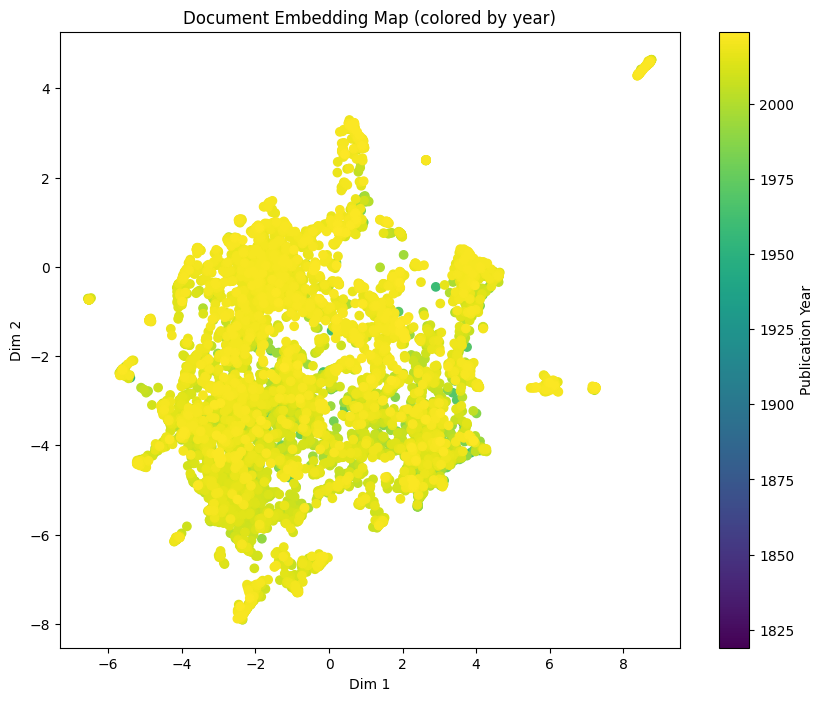

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.decomposition import PCA

# =========================
# 1. LOAD DATA
# =========================
path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# =========================
# 2. BUILD DOCUMENTS
# =========================
documents = []
for paper_id, paper in data.items():
    title = paper.get("title", "")
    keywords = paper.get("keywords", [])
    
    content = f"{title}. {' '.join(keywords)}"
    
    year = paper.get("pub_year")
    if not year:
        continue
    
    documents.append({
        "id": paper_id,
        "content": content,
        "year": year
    })

texts = [d["content"] for d in documents]
years = np.array([d["year"] for d in documents])

print("Num docs:", len(texts))

# =========================
# 3. EMBEDDING
# =========================
# OPTION 1: fast
# embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# OPTION 2: better quality
embedding_model = SentenceTransformer("all-mpnet-base-v2")

embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True
)

# =========================
# 4. DIMENSION REDUCTION
# =========================

# --- OPTION A: UMAP (recommended)
umap_model = UMAP(
    n_neighbors=30,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

embeddings_2d = umap_model.fit_transform(embeddings)

# --- OPTION B: PCA (fallback)
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(embeddings)

# =========================
# 5. VISUALIZATION
# =========================

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=years,
)

plt.title("Document Embedding Map (colored by year)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Publication Year")

plt.show()

Total docs: 8253
Year range: 1819 - 2024


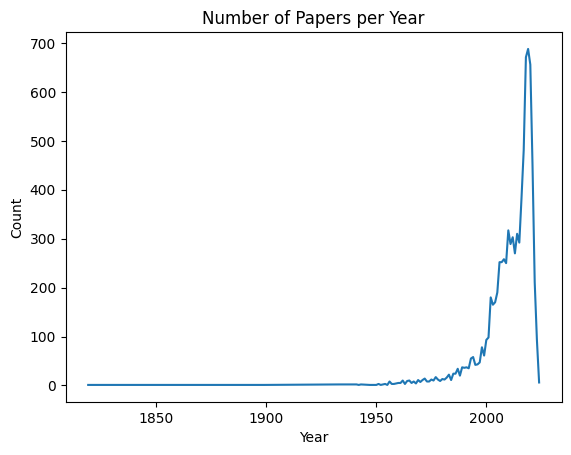

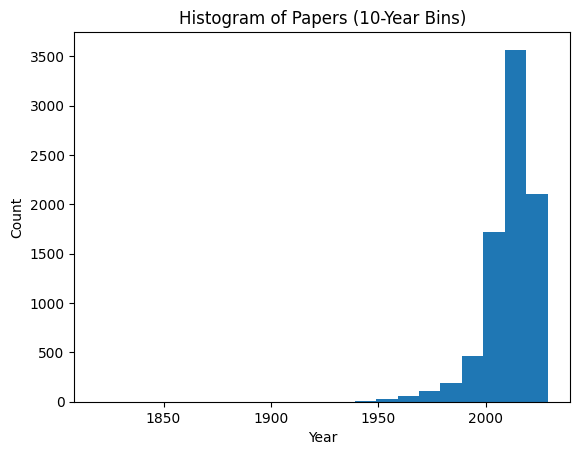

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# =========================
# 1. LOAD DATA
# =========================
path = r"D:\timelline-generator\data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# =========================
# 2. EXTRACT YEARS
# =========================
years = []

for paper in data.values():
    y = paper.get("pub_year")
    if y:
        years.append(y)

years = np.array(years)

print("Total docs:", len(years))
print("Year range:", years.min(), "-", years.max())

# =========================
# 3. COUNT PER YEAR
# =========================
year_counts = Counter(years)

sorted_years = sorted(year_counts.keys())
counts = [year_counts[y] for y in sorted_years]

# =========================
# 4. LINE PLOT (YEARLY COUNT)
# =========================
plt.figure()
plt.plot(sorted_years, counts)

plt.title("Number of Papers per Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

# =========================
# 5. HISTOGRAM (10-YEAR BIN)
# =========================
min_year = years.min()
max_year = years.max()

bins = np.arange(min_year, max_year + 10, 10)

plt.figure()
plt.hist(years, bins=bins)

plt.title("Histogram of Papers (10-Year Bins)")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

In [3]:
print("Min year:", years.min())
print("Max year:", years.max())
print("Mean year:", years.mean())
print("Median year:", np.median(years))

print("\nQuantiles:")
for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f"{q}: {np.quantile(years, q)}")

Min year: 1819
Max year: 2024
Mean year: 2010.706288622319
Median year: 2014.0

Quantiles:
0.1: 1998.0
0.25: 2006.0
0.5: 2014.0
0.75: 2019.0
0.9: 2020.0


Total keywords: 570641
Distinct keywords: 48390


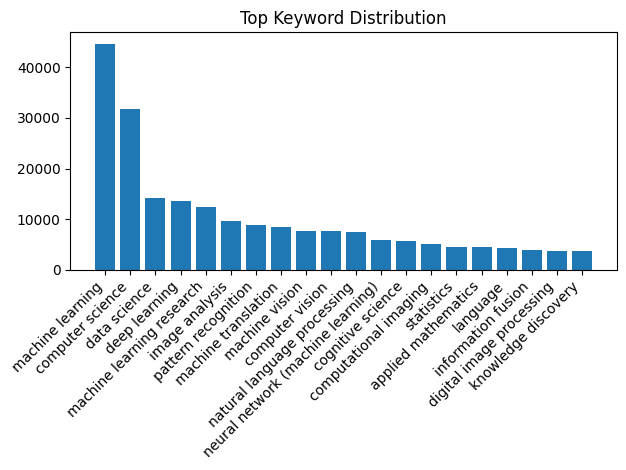

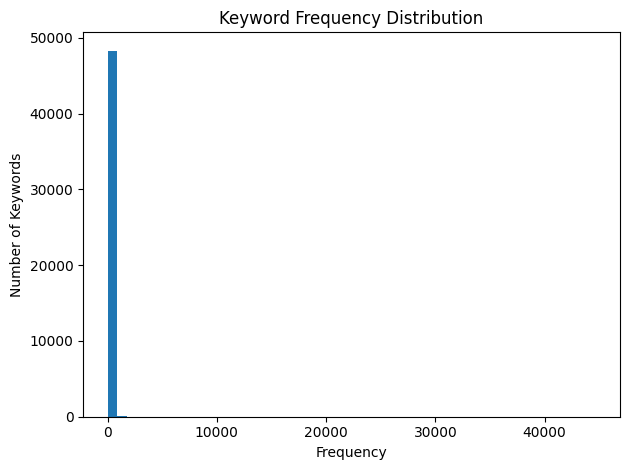

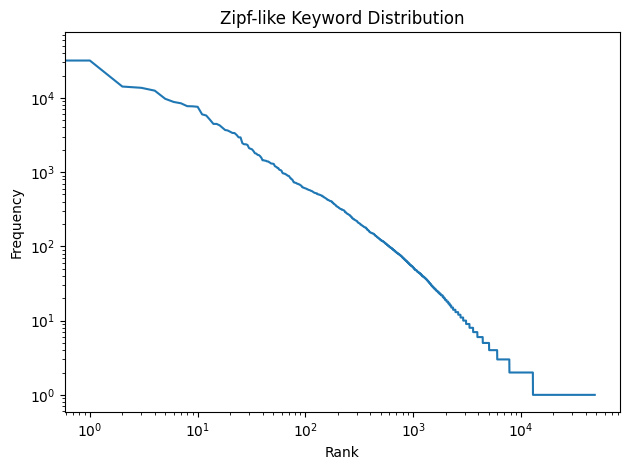

In [1]:
import json
from collections import Counter
import matplotlib.pyplot as plt

paths = [
    r"D:\timelline-generator\data\machine_learning_docs_info.json",
    r"D:\timelline-generator\data\machine_translation_docs_info.json"
]

all_keywords = []

for path in paths:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for doc_id, doc in data.items():
        kws = doc.get("keywords", [])
        for kw in kws:
            kw = kw.lower().strip()
            if kw:
                all_keywords.append(kw)

total_keywords = len(all_keywords)
distinct_keywords = len(set(all_keywords))

print("Total keywords:", total_keywords)
print("Distinct keywords:", distinct_keywords)

freq = Counter(all_keywords)

top_k = 20
common = freq.most_common(top_k)

words = [w for w, _ in common]
counts = [c for _, c in common]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Top Keyword Distribution")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(freq.values(), bins=50)
plt.title("Keyword Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Keywords")
plt.tight_layout()
plt.show()

sorted_freq = sorted(freq.values(), reverse=True)

plt.figure()
plt.plot(sorted_freq)
plt.yscale("log")
plt.xscale("log")
plt.title("Zipf-like Keyword Distribution")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [3]:
import json
import pandas as pd

path = r"data\machine_learning_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# lấy year từ dict values
years = []

for doc_id, doc in data.items():
    year = doc.get("pub_year")
    if year is not None:
        years.append(year)

df = (
    pd.DataFrame(years, columns=["year"])
    .value_counts()
    .reset_index(name="num_docs")
    .sort_values("year")
)
pd.set_option('display.max_rows', None)

print(df)

     year  num_docs
135  1744         1
123  1801         1
118  1819         1
119  1842         1
120  1852         1
121  1856         1
122  1859         1
111  1865         2
124  1886         1
125  1888         1
117  1891         1
127  1892         1
126  1893         1
110  1895         2
129  1898         1
108  1899         2
131  1902         1
106  1903         2
98   1905         4
133  1906         1
107  1907         2
134  1909         1
103  1910         3
109  1911         2
99   1912         4
90   1913         6
96   1914         5
116  1915         1
102  1917         3
128  1918         1
113  1919         2
114  1920         2
132  1921         1
101  1922         4
130  1923         1
112  1924         2
105  1925         3
100  1926         4
115  1927         2
85   1928         9
94   1929         5
89   1930         6
88   1931         7
86   1932         8
97   1933         5
93   1934         5
91   1935         6
104  1936         3
87   1937         7


In [4]:
import json
import pandas as pd

path = r"data\machine_translation_docs_info.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# lấy year từ dict values
years = []

for doc_id, doc in data.items():
    year = doc.get("pub_year")
    if year is not None:
        years.append(year)

df = (
    pd.DataFrame(years, columns=["year"])
    .value_counts()
    .reset_index(name="num_docs")
    .sort_values("year")
)
pd.set_option('display.max_rows', None)

print(df)

    year  num_docs
83  1819         1
77  1852         1
75  1899         1
73  1933         2
74  1941         2
76  1942         1
72  1943         2
78  1947         1
79  1949         1
80  1950         1
70  1951         3
81  1952         1
71  1953         2
69  1954         3
82  1955         1
57  1956         8
68  1957         3
67  1958         3
64  1959         4
63  1960         5
62  1961         5
52  1962        10
66  1963         3
54  1964         9
51  1965        10
61  1966         5
56  1967         8
65  1968         4
47  1969        11
59  1970         7
48  1971        11
42  1972        14
55  1973         8
58  1974         8
44  1975        12
50  1976        10
40  1977        17
45  1978        12
53  1979         9
43  1980        13
46  1981        12
41  1982        16
38  1983        22
49  1984        11
37  1985        24
36  1986        24
35  1987        34
39  1988        20
32  1989        37
33  1990        36
31  1991        37
34  1992    

In [2]:
import numpy as np
import math

# -----------------------------
# Fake cost
# -----------------------------
def segment_cost(seg_dists, seg_embs):
    d = np.stack(seg_dists)
    e = np.stack(seg_embs)
    return np.var(d) + 0.1 * np.var(e)


# -----------------------------
# Fake data
# -----------------------------
def make_fake_data(n=10, dim=3):
    np.random.seed(42)
    return (
        [np.random.dirichlet(np.ones(5)) for _ in range(n)],
        [np.random.randn(dim) for _ in range(n)]
    )


# -----------------------------
# Render segmentation
# -----------------------------
def render_segments(prev, i):
    segments = []
    cur = i

    while cur > 0:
        j = prev[cur]
        segments.append((j, cur - 1))
        cur = j

    segments.reverse()

    out = []
    for l, r in segments:
        block = " ".join([f"s{k+1}" for k in range(l, r+1)])
        out.append(block)

    return " | ".join(out)


# -----------------------------
# DP with live visualization
# -----------------------------
def build_dp_viz(year_dists, year_embs, lambda_penalty=0.5):
    n = len(year_dists)

    cost_cache = {}

    def get_cost(i, j):
        if (i, j) in cost_cache:
            return cost_cache[(i, j)]

        cost_cache[(i, j)] = segment_cost(
            year_dists[i:j+1],
            year_embs[i:j+1]
        )
        return cost_cache[(i, j)]

    dp = [math.inf] * (n + 1)
    prev = [-1] * (n + 1)

    dp[0] = 0

    for i in range(1, n + 1):
        print("\n" + "="*60)
        print(f"STEP i = {i}")

        best_cost = math.inf
        best_j = -1

        for j in range(i):
            cost = dp[j] + get_cost(j, i - 1) + lambda_penalty

            print(f"j={j} | dp={dp[j]:.3f} | cost={cost:.3f}")

            if cost < best_cost:
                best_cost = cost
                best_j = j

        dp[i] = best_cost
        prev[i] = best_j

        # -----------------------------
        # VISUALIZE AFTER EACH i
        # -----------------------------
        print("\nCURRENT SEGMENTATION:")
        print(render_segments(prev, i))

    # final
    print("\nFINAL:")
    print(render_segments(prev, n))

    return prev


# -----------------------------
# RUN
# -----------------------------
dists, embs = make_fake_data(10)
prev = build_dp_viz(dists, embs)


STEP i = 1
j=0 | dp=0.000 | cost=0.541

CURRENT SEGMENTATION:
s1

STEP i = 2
j=0 | dp=0.000 | cost=0.576
j=1 | dp=0.541 | cost=1.092

CURRENT SEGMENTATION:
s1 s2

STEP i = 3
j=0 | dp=0.000 | cost=0.590
j=1 | dp=0.541 | cost=1.146
j=2 | dp=0.576 | cost=1.169

CURRENT SEGMENTATION:
s1 s2 s3

STEP i = 4
j=0 | dp=0.000 | cost=0.593
j=1 | dp=0.541 | cost=1.141
j=2 | dp=0.576 | cost=1.185
j=3 | dp=0.590 | cost=1.172

CURRENT SEGMENTATION:
s1 s2 s3 s4

STEP i = 5
j=0 | dp=0.000 | cost=0.592
j=1 | dp=0.541 | cost=1.141
j=2 | dp=0.576 | cost=1.175
j=3 | dp=0.590 | cost=1.184
j=4 | dp=0.593 | cost=1.157

CURRENT SEGMENTATION:
s1 s2 s3 s4 s5

STEP i = 6
j=0 | dp=0.000 | cost=0.590
j=1 | dp=0.541 | cost=1.137
j=2 | dp=0.576 | cost=1.170
j=3 | dp=0.590 | cost=1.179
j=4 | dp=0.593 | cost=1.168
j=5 | dp=0.592 | cost=1.171

CURRENT SEGMENTATION:
s1 s2 s3 s4 s5 s6

STEP i = 7
j=0 | dp=0.000 | cost=0.589
j=1 | dp=0.541 | cost=1.136
j=2 | dp=0.576 | cost=1.166
j=3 | dp=0.590 | cost=1.177
j=4 | dp=0.593 